# Iceland snowmelt runoff onset — regional viewer

Exploratory regional maps (**not** manuscript figures): the multi-year median runoff
onset over a hillshade, the same map with a zoomed-out context inset, and per-water-year
anomalies against that median.

Data comes from the **multiscale visualization pyramid** ([`../../pyramid/`](../../pyramid/)),
read one level at a time with `build_pyramid.open_pyramid_level` — the same source the global
figures use. The pre-v10 path (full-resolution store + `.coarsen(3, 3)`) is retired.

Styling, per-variable colour limits, scalebars and the context inset all come from
`global_snowmelt_runoff_onset.plot_utils`, whose module docstring is the repository's
**figure conventions** reference. Figures are written to `figures/<config.version>/`, so the
v9 renders in `figures/v9/` stay side by side with the v10 ones.


In [1]:
import os
import sys

import geopandas as gpd
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import rioxarray  # noqa: F401  -- registers the .rio accessor
from matplotlib.gridspec import GridSpec

from global_snowmelt_runoff_onset.config import Config
from global_snowmelt_runoff_onset.plot_utils import (
    HILLSHADE_KW,
    add_context_inset,
    add_scalebar,
    create_diverging_colorbar,
    create_month_colorbar,
    load_hillshade,
    orthographic_locator_map,
    style_map_axes,
    variable_kw,
)

# consumer-side pyramid reader, same convention as visualize/global/ and visualize/methods/
sys.path.insert(0, '../../pyramid')
from build_pyramid import open_pyramid_level


In [2]:
config = Config('config/global_config_v10.txt')

# figures are versioned like results/: the v9 renders stay in figures/v9/
FIG_DIR = f'figures/{config.version}'
os.makedirs(FIG_DIR, exist_ok=True)

# Read the multiscale visualization pyramid (visualize/pyramid/) -- the v9 path
# (full-resolution store + .coarsen(3, 3)) is retired and unavailable for v10.
# Level n is ~80 m * 2**n: level 2 (~320 m) is the closest analogue to the v9
# 240 m display grid; level 5 (~2.6 km) is plenty for the zoomed-out inset.
REGION_LEVEL = 2
CONTEXT_LEVEL = 5

# How far past the region outline each view extends, in projected metres.
# MAP_BUFFER gives the main map some surroundings instead of cropping hard to
# the outline; CONTEXT_BUFFER is the inset's much wider footprint.
MAP_BUFFER = 80_000
CONTEXT_BUFFER = 800_000


SAS token is valid until 2026-08-26 19:52 UTC (325.9 hours)


----------------------------------------
Configuration loaded:
config_name = global_config_v10
version = v10
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 84.048
bbox_bottom = -63.4074
expected_grid_shape = 204800, 499998
expected_tile_grid = 100, 245
wy_start = 2015
wy_end = 2025
trailing_buffer_days = 120
low_backscatter_threshold = 0.001
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow_v10.geojson
global_runoff_icechunk_azure_prefix = snowmelt/snowmelt_runoff_onset/global_runoff_onset_v10
release_tag = v10.0
global_runoff_multiscale_azure_prefix = snowmelt/snowmelt_runoff_onset/global_runoff_onset_v10_multiscale_1
multiscale

## Region of interest

Everything is plotted in a projected, metre-based CRS (plot_utils convention 4) so shapes, areas and the scalebar are all honest.

In [3]:
world_gdf = gpd.read_file(
    'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')
iceland_gdf = world_gdf[world_gdf['ADMIN'] == 'Iceland']

# the island's own UTM zone (27N), picked from its bounds
REGION_CRS = iceland_gdf.estimate_utm_crs()
iceland_gdf.to_crs(REGION_CRS)


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
144,Admin-0 country,1,3,Iceland,ISL,0,2,Sovereign country,1,Iceland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((788927.287 7385752.266, 785883.849 7..."


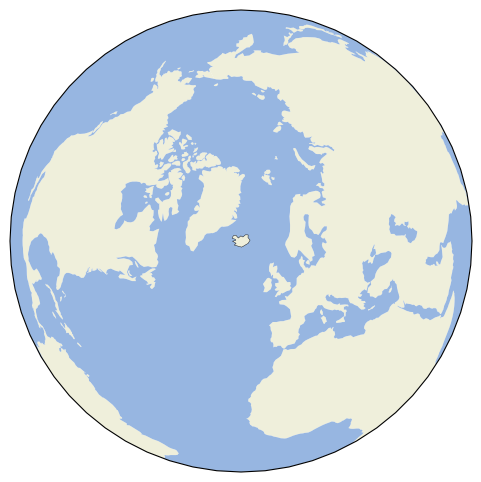

In [4]:
ax = orthographic_locator_map(iceland_gdf)
ax.figure.savefig(f'{FIG_DIR}/orthographic_context_map.png',
                  dpi=300, transparent=True)


## Hillshade and pyramid read

In [5]:
# hillshades for the two view scales, both reprojected into REGION_CRS. The
# extra 50 km keeps the reprojected edge outside the plotted extent.
iceland_hillshade_da = load_hillshade(iceland_gdf, buffer=MAP_BUFFER + 50_000, crs=REGION_CRS)
iceland_context_hillshade_da = load_hillshade(iceland_gdf, buffer=CONTEXT_BUFFER, crs=REGION_CRS)
iceland_hillshade_da


<xarray.DataArray (y: 862, x: 1146)> Size: 4MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(862, 1146), dtype=float32)
Coordinates:
  * y            (y) float64 7kB 7.559e+06 7.559e+06 ... 6.88e+06 6.879e+06
  * x            (x) float64 9kB 2.033e+05 2.041e+05 ... 1.108e+06 1.109e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:        Adobe Photoshop CS5 Macintosh
    TIFFTAG_DATETIME:        2012:07:20 09:39:49
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0
    _FillValue:              nan

In [6]:
iceland_ds = (
    open_pyramid_level(config, REGION_LEVEL)[['runoff_onset_median', 'runoff_onset']]
    .rio.write_crs('EPSG:4326')
    .rio.clip_box(*iceland_gdf.to_crs(REGION_CRS).buffer(MAP_BUFFER + 5_000).total_bounds,
                  crs=REGION_CRS)
    .astype('float32')
    .compute()
    .rio.reproject(REGION_CRS)
)
iceland_ds


<xarray.Dataset> Size: 848MB
Dimensions:              (x: 4940, y: 3578, water_year: 11)
Coordinates:
  * x                    (x) float64 40kB 2.155e+05 2.156e+05 ... 1.011e+06
  * y                    (y) float64 29kB 7.506e+06 7.506e+06 ... 6.93e+06
  * water_year           (water_year) int64 88B 2015 2016 2017 ... 2024 2025
    spatial_ref          int64 8B 0
Data variables:
    runoff_onset_median  (y, x) float32 71MB nan nan nan nan ... nan nan nan nan
    runoff_onset         (water_year, y, x) float32 778MB nan nan ... nan nan
Attributes:
    title:           Global snowmelt runoff onset from Sentinel-1 SAR
    config_version:  v10

In [7]:
iceland_ds['runoff_onset_anomaly'] = (
    iceland_ds['runoff_onset'] - iceland_ds['runoff_onset_median'])

water_years = iceland_ds['water_year'].values
N_YEARS = len(water_years)

# every view in this notebook shares one extent, so panels are comparable
REGION_BOUNDS = iceland_gdf.to_crs(REGION_CRS).buffer(MAP_BUFFER).total_bounds

# styling comes from the per-variable convention in plot_utils, not from
# hand-written cmap/vmin/vmax here (plot_utils convention 1)
MEDIAN_KW = variable_kw('runoff_onset_median')
ANOM_KW = variable_kw('runoff_onset_anomaly')

# year counts are derived, never hardcoded (plot_utils convention 3)
MEDIAN_LABEL = f'{N_YEARS}-year median runoff onset date [day of water year]'
EARLIER_TEXT = f'earlier than {N_YEARS}-yr median'
LATER_TEXT = f'later than {N_YEARS}-yr median'

print(f'{N_YEARS} water years: WY{water_years.min()}-WY{water_years.max()}')
print(f'{REGION_CRS}, extent {(REGION_BOUNDS[2] - REGION_BOUNDS[0]) / 1e3:.0f} x '
      f'{(REGION_BOUNDS[3] - REGION_BOUNDS[1]) / 1e3:.0f} km')


11 water years: WY2015-WY2025
EPSG:32627, extent 659 x 504 km


## Median runoff onset map

Two renders of the same map: bare, and with a zoomed-out context inset that reuses the identical variable, hillshade, colormap and limits.

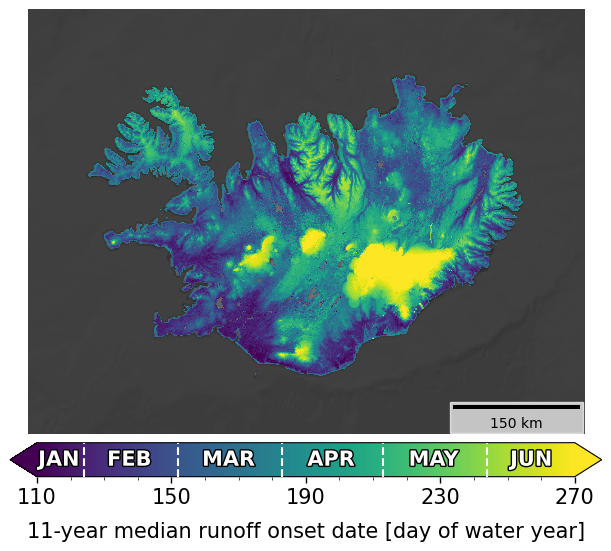

In [8]:
fig = plt.figure(figsize=(6, 5.4), layout='constrained')
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 0.08], hspace=0.00)
ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

iceland_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
iceland_ds['runoff_onset_median'].plot.imshow(ax=ax, add_colorbar=False, zorder=1,
                                          **MEDIAN_KW)
style_map_axes(ax, REGION_BOUNDS)
add_scalebar(ax, location='lower right')

create_month_colorbar(MEDIAN_KW['vmin'], MEDIAN_KW['vmax'], hemisphere='northern',
                      ax=cax, label=MEDIAN_LABEL)

fig.savefig(f'{FIG_DIR}/median_runoff_onset_map.png', dpi=300, bbox_inches='tight')


In [9]:
# same variable, coarser level, much wider footprint -- the inset's content
iceland_context_da = (
    open_pyramid_level(config, CONTEXT_LEVEL)['runoff_onset_median']
    .rio.write_crs('EPSG:4326')
    .rio.clip_box(*iceland_gdf.to_crs(REGION_CRS).buffer(CONTEXT_BUFFER).total_bounds,
                  crs=REGION_CRS)
    .astype('float32')
    .compute()
    .rio.reproject(REGION_CRS)
)
iceland_context_da


<xarray.DataArray 'runoff_onset_median' (y: 1926, x: 3107)> Size: 24MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1926, 3107), dtype=float32)
Coordinates:
  * y            (y) float64 15kB 8.465e+06 8.464e+06 ... 6.093e+06 6.092e+06
  * x            (x) float64 25kB -1.274e+06 -1.273e+06 ... 2.554e+06 2.555e+06
    spatial_ref  int64 8B 0
Attributes:
    description:  Median estimated day of water year of snowmelt runoff onset...
    _FillValue:   nan

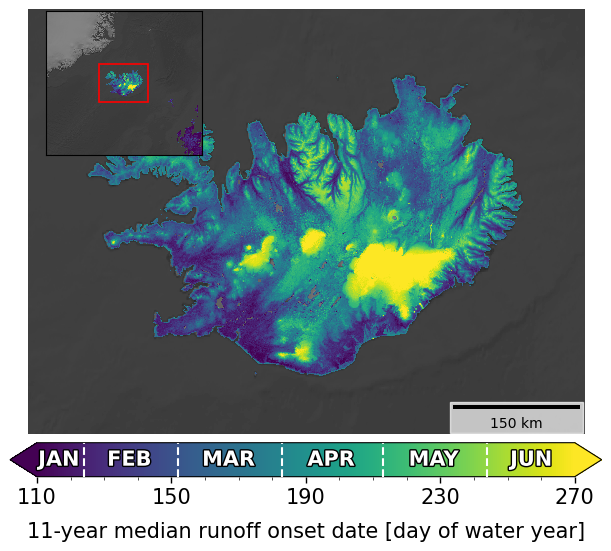

In [10]:
fig = plt.figure(figsize=(6, 5.4), layout='constrained')
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 0.08], hspace=0.00)
ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

iceland_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
iceland_ds['runoff_onset_median'].plot.imshow(ax=ax, add_colorbar=False, zorder=1,
                                          **MEDIAN_KW)
style_map_axes(ax, REGION_BOUNDS)

# Identical variable, hillshade, colormap and limits -- just zoomed out. The red
# box is this map's extent, read straight off its limits. Explicit `bounds` (the
# buffered region box) crops the NaN corners that reprojecting a lon/lat clip
# into a metric CRS leaves behind.
add_context_inset(ax, iceland_context_da, iceland_context_hillshade_da,
                  loc='upper left', size='34%', borderpad=0.1,
                  data_kw=MEDIAN_KW,
                  bounds=iceland_gdf.to_crs(REGION_CRS).buffer(CONTEXT_BUFFER).total_bounds)

# scalebar opposite the inset so the two never compete for a corner
add_scalebar(ax, location='lower right')

create_month_colorbar(MEDIAN_KW['vmin'], MEDIAN_KW['vmax'], hemisphere='northern',
                      ax=cax, label=MEDIAN_LABEL)

fig.savefig(f'{FIG_DIR}/median_runoff_onset_map_with_context.png',
            dpi=300, bbox_inches='tight')


## Per-water-year anomaly maps

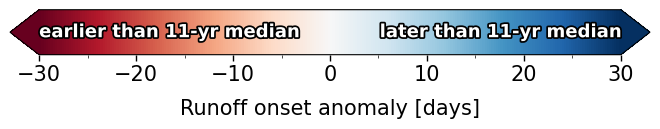

In [11]:
# standalone colorbar, for pasting alongside the *_no_cbar grids. Default ticks
# already land on -30..30 by 10, so only the minor spacing needs stating.
figcbar = create_diverging_colorbar(
    ANOM_KW['vmin'], ANOM_KW['vmax'], cmap=ANOM_KW['cmap'],
    label='Runoff onset anomaly [days]',
    minor_tick_spacing=5,
    left_text=EARLIER_TEXT, right_text=LATER_TEXT,
)
figcbar.savefig(f'{FIG_DIR}/runoff_onset_anomaly_colorbar_horizontal.png',
                bbox_inches='tight', dpi=300, facecolor='white', pad_inches=0.1)


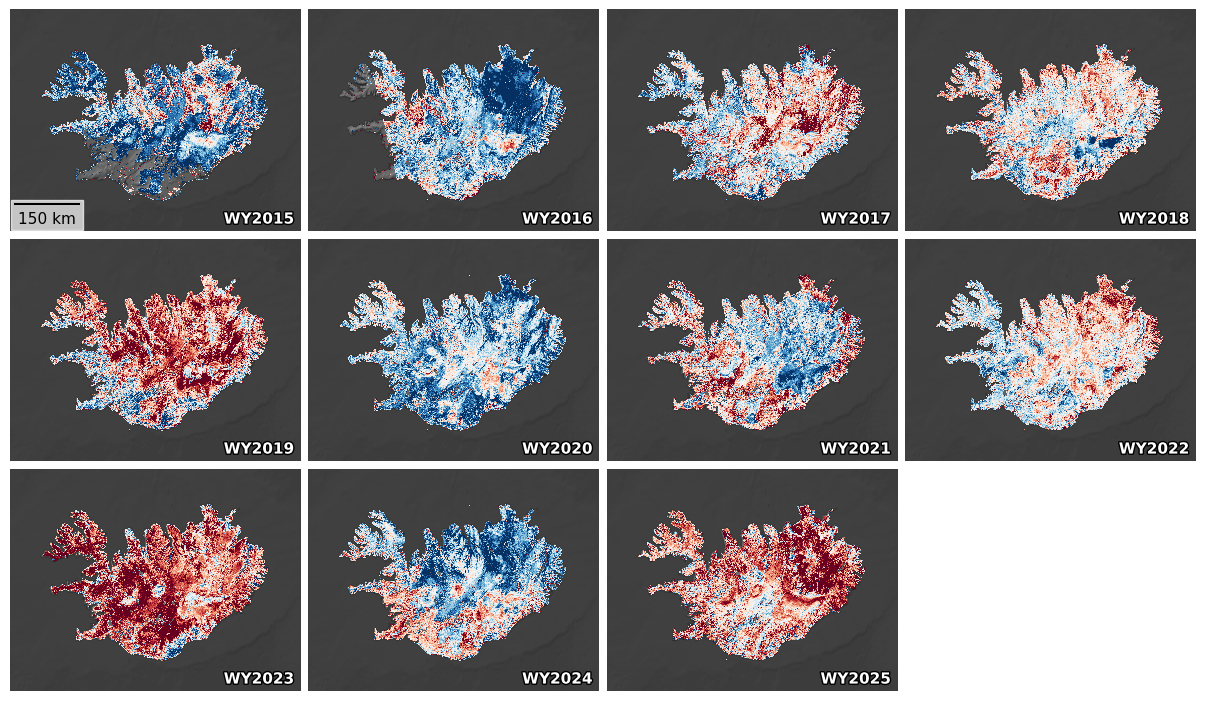

In [12]:
# 3 x 4 = 12 panel slots; leftovers stay blank.
# layout='compressed' squeezes the dead space that equal-aspect panels
# otherwise leave inside their grid cells -- no wspace/hspace tuning needed.
NROWS, NCOLS = 3, 4
fig, axgrid = plt.subplots(NROWS, NCOLS, figsize=(12.0, 6.9), layout='compressed')
axs = list(axgrid.flat)
for ax in axs:
    ax.axis('off')

for i, (wy, ax) in enumerate(zip(water_years, axs)):
    iceland_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
    iceland_ds['runoff_onset_anomaly'].sel(water_year=wy).plot.imshow(
        ax=ax, add_colorbar=False, zorder=1, **ANOM_KW)
    ax.text(0.98, 0.02, f'WY{wy}', transform=ax.transAxes,
            ha='right', va='bottom', color='white', fontweight='bold',
            fontsize=11,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='black')])
    style_map_axes(ax, REGION_BOUNDS)
    if i == 0:  # every panel shares REGION_BOUNDS, so one scalebar is enough
        add_scalebar(ax, location='lower left', font_properties={'size': 11})

fig.savefig(f'{FIG_DIR}/anomaly_maps_{NROWS}{NCOLS}grid_no_cbar.png',
            dpi=300, bbox_inches='tight')


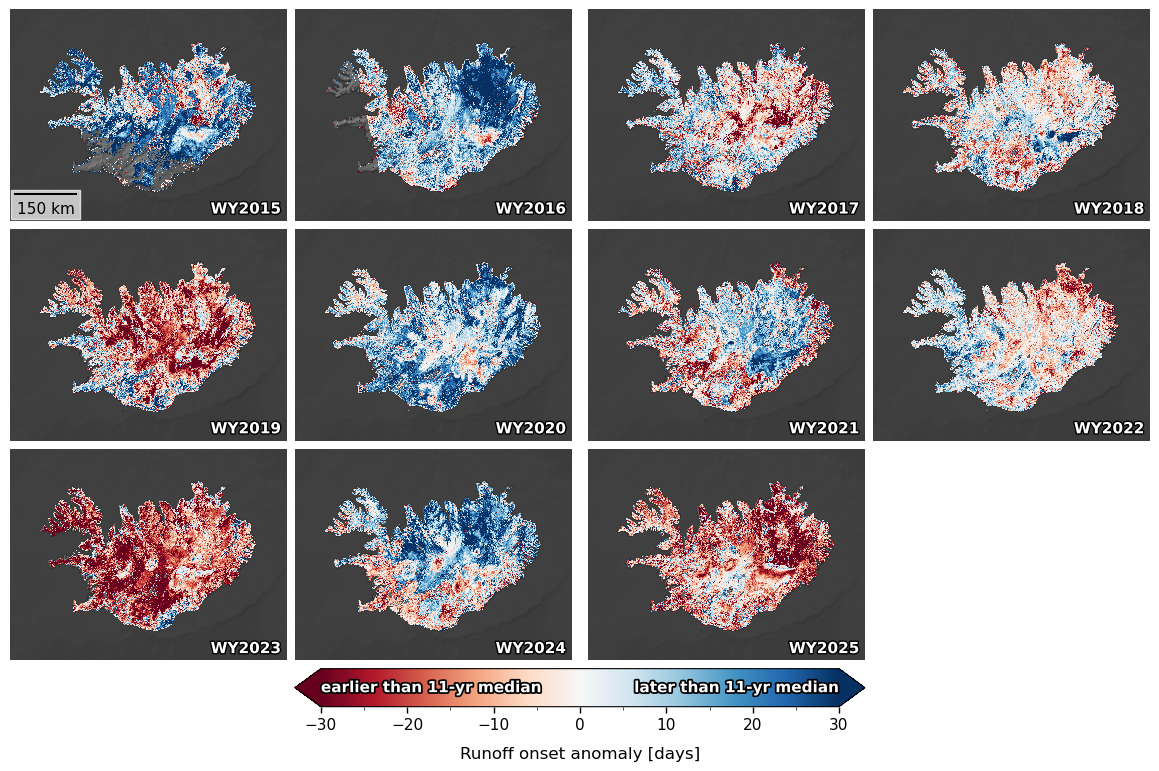

In [13]:
# 3 x 4 map grid plus a dedicated thin colorbar row underneath
NROWS, NCOLS = 3, 4
fig = plt.figure(figsize=(12.0, 7.6), layout='compressed')
gs = GridSpec(NROWS + 1, NCOLS, figure=fig,
              height_ratios=[1] * NROWS + [0.18])

axs = [fig.add_subplot(gs[r, c]) for r in range(NROWS) for c in range(NCOLS)]
for ax in axs:
    ax.axis('off')

for i, (wy, ax) in enumerate(zip(water_years, axs)):
    iceland_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
    iceland_ds['runoff_onset_anomaly'].sel(water_year=wy).plot.imshow(
        ax=ax, add_colorbar=False, zorder=1, **ANOM_KW)
    ax.text(0.98, 0.02, f'WY{wy}', transform=ax.transAxes,
            ha='right', va='bottom', color='white', fontweight='bold',
            fontsize=11,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='black')])
    style_map_axes(ax, REGION_BOUNDS)
    if i == 0:  # every panel shares REGION_BOUNDS, so one scalebar is enough
        add_scalebar(ax, location='lower left', font_properties={'size': 11})

# create_diverging_colorbar shrinks the end annotations to fit this narrower
# axes, so they can't collide mid-bar
cax = fig.add_subplot(gs[NROWS, 1:3])
create_diverging_colorbar(
    ANOM_KW['vmin'], ANOM_KW['vmax'], cmap=ANOM_KW['cmap'], ax=cax,
    label='Runoff onset anomaly [days]',
    minor_tick_spacing=5,
    left_text=EARLIER_TEXT, right_text=LATER_TEXT,
    label_fontsize=12, tick_labelsize=11,
    text_fontsize=12,
)

fig.savefig(f'{FIG_DIR}/anomaly_maps_{NROWS}{NCOLS}grid_w_cbar.png',
            dpi=300, bbox_inches='tight')


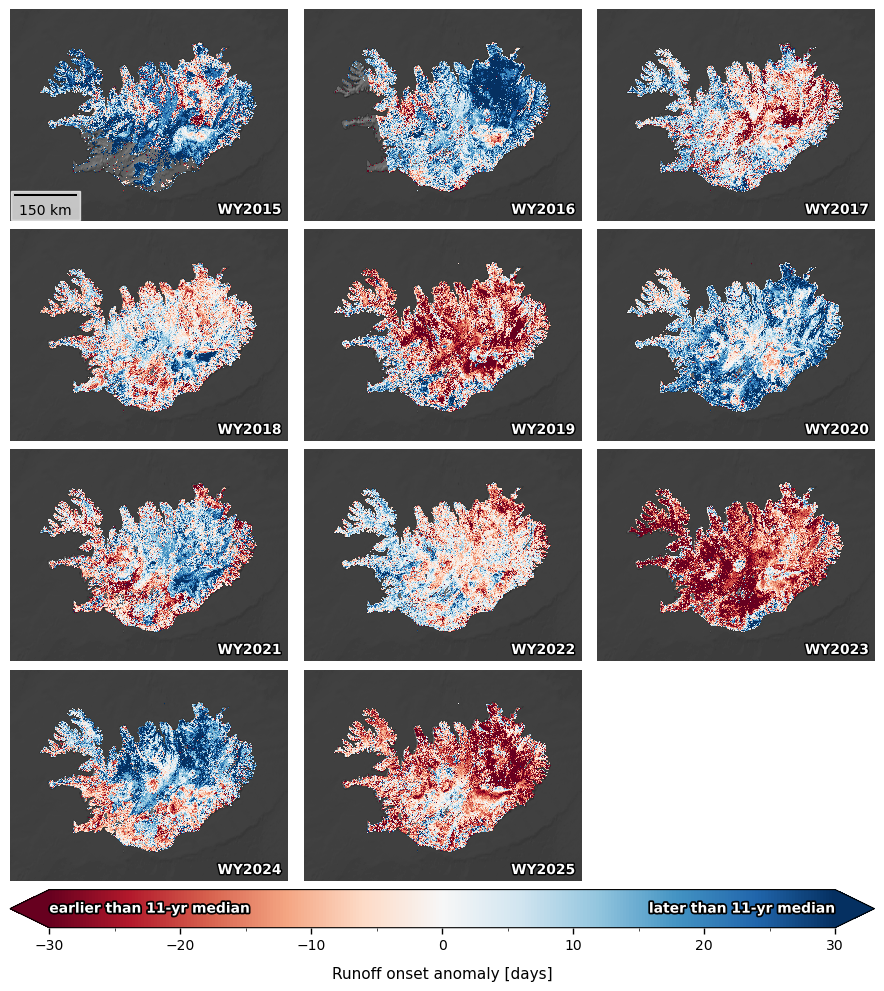

In [14]:
# 4 x 3 map grid plus a dedicated thin colorbar row underneath
NROWS, NCOLS = 4, 3
fig = plt.figure(figsize=(9.0, 9.8), layout='compressed')
gs = GridSpec(NROWS + 1, NCOLS, figure=fig,
              height_ratios=[1] * NROWS + [0.18])

axs = [fig.add_subplot(gs[r, c]) for r in range(NROWS) for c in range(NCOLS)]
for ax in axs:
    ax.axis('off')

for i, (wy, ax) in enumerate(zip(water_years, axs)):
    iceland_hillshade_da.plot.imshow(ax=ax, **HILLSHADE_KW)
    iceland_ds['runoff_onset_anomaly'].sel(water_year=wy).plot.imshow(
        ax=ax, add_colorbar=False, zorder=1, **ANOM_KW)
    ax.text(0.98, 0.02, f'WY{wy}', transform=ax.transAxes,
            ha='right', va='bottom', color='white', fontweight='bold',
            fontsize=10,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='black')])
    style_map_axes(ax, REGION_BOUNDS)
    if i == 0:  # every panel shares REGION_BOUNDS, so one scalebar is enough
        add_scalebar(ax, location='lower left', font_properties={'size': 10})

# create_diverging_colorbar shrinks the end annotations to fit this narrower
# axes, so they can't collide mid-bar
cax = fig.add_subplot(gs[NROWS, 0:3])
create_diverging_colorbar(
    ANOM_KW['vmin'], ANOM_KW['vmax'], cmap=ANOM_KW['cmap'], ax=cax,
    label='Runoff onset anomaly [days]',
    minor_tick_spacing=5,
    left_text=EARLIER_TEXT, right_text=LATER_TEXT,
    label_fontsize=11, tick_labelsize=10,
    text_fontsize=10,
)

fig.savefig(f'{FIG_DIR}/anomaly_maps_{NROWS}{NCOLS}grid_w_cbar.png',
            dpi=300, bbox_inches='tight')
